<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%2005/Part_B_and_Q_1%2C2%2C3%2C4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part B – Synthetic Multi-Sensor Asset Dataset

Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display settings
pd.set_option('display.max_columns', None)

Generate the Required Dataset

In [2]:
# =====================================================
# Synthetic Multi-Sensor Asset Data
# =====================================================

np.random.seed(42)

n_samples = 2500

# Latent physical factors
f1 = np.random.normal(0, 1, n_samples)
f2 = np.random.normal(0, 1, n_samples)

# Observable sensors

# Sensor 1
s1 = 0.85*f1 + 0.10*f2 + np.random.normal(0,0.30,n_samples)

# Sensor 2
s2 = 0.80*f1 + 0.15*f2 + np.random.normal(0,0.35,n_samples)

# Sensor 3
s3 = 0.12*f1 + 0.90*f2 + np.random.normal(0,0.25,n_samples)

# Sensor 4
s4 = 0.02*f1 + 0.05*f2 + np.random.normal(0,1.40,n_samples)

# Create dataframe
df_asset = pd.DataFrame(
    np.vstack([s1,s2,s3,s4]).T,
    columns=[
        'Sensor_1',
        'Sensor_2',
        'Sensor_3',
        'Sensor_4'
    ]
)

print("Dataset Shape:", df_asset.shape)

df_asset.head()

Dataset Shape: (2500, 4)


,Sensor_1,Sensor_2,Sensor_3,Sensor_4
0,0.352140,1.086956,0.403534,0.753495
1,-0.156730,0.077262,0.778400,-1.379485
2,-0.021289,0.732151,-0.369800,-1.065461
3,1.134325,1.161528,-0.340645,-1.371333
4,-0.087697,-0.583662,-0.705439,-0.252842


Dataset Summary

In [3]:
print("Summary Statistics")
display(df_asset.describe())

Summary Statistics


,Sensor_1,Sensor_2,Sensor_3,Sensor_4
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.017835,0.026759,-0.019442,0.046955
std,0.891317,0.874048,0.944303,1.420302
min,-2.817287,-2.817798,-3.104605,-4.698508
25%,-0.566040,-0.566549,-0.650161,-0.941562
50%,0.008593,0.027483,0.005935,0.055618
75%,0.604435,0.624583,0.604576,0.994883
max,3.449863,3.009531,3.262463,4.747401


Covariance Matrix

Covariance Matrix


,Sensor_1,Sensor_2,Sensor_3,Sensor_4
Sensor_1,0.794446,0.669456,0.164570,0.044917
Sensor_2,0.669456,0.763960,0.220062,0.049090
Sensor_3,0.164570,0.220062,0.891709,0.075915
Sensor_4,0.044917,0.049090,0.075915,2.017258


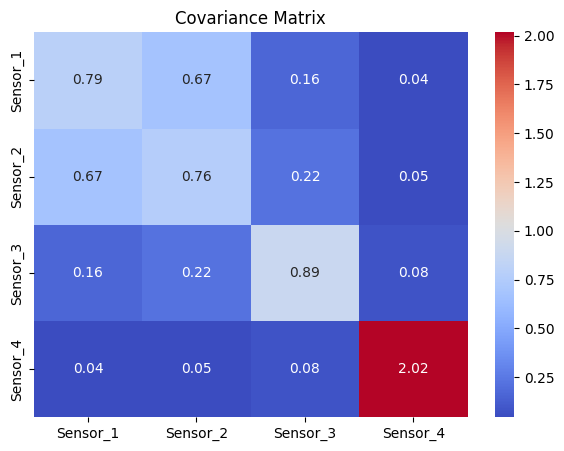

In [4]:
cov_matrix = df_asset.cov()

print("Covariance Matrix")
display(cov_matrix)

plt.figure(figsize=(7,5))
sns.heatmap(
    cov_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Covariance Matrix")
plt.show()

Correlation Matrix

Correlation Matrix


,Sensor_1,Sensor_2,Sensor_3,Sensor_4
Sensor_1,1.000000,0.859319,0.195527,0.035481
Sensor_2,0.859319,1.000000,0.266624,0.039543
Sensor_3,0.195527,0.266624,1.000000,0.056603
Sensor_4,0.035481,0.039543,0.056603,1.000000


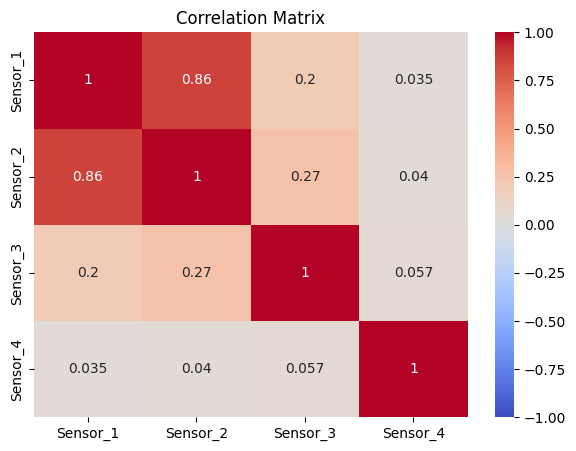

In [5]:
corr_matrix = df_asset.corr()

print("Correlation Matrix")
display(corr_matrix)

plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()

Interpretation

In [6]:
print("""
Observations:

1. Sensor_1 and Sensor_2 show strong positive correlation.
   Both are heavily influenced by latent factor f1.

2. Sensor_3 has moderate correlation with Sensors 1 and 2.
   It is mainly driven by latent factor f2.

3. Sensor_4 exhibits weak correlations with all sensors.
   This is expected because it contains substantial random noise.

4. Sensor_4 also shows the largest variance due to its high noise level.
""")


Observations:

1. Sensor_1 and Sensor_2 show strong positive correlation.
   Both are heavily influenced by latent factor f1.

2. Sensor_3 has moderate correlation with Sensors 1 and 2.
   It is mainly driven by latent factor f2.

3. Sensor_4 exhibits weak correlations with all sensors.
   This is expected because it contains substantial random noise.

4. Sensor_4 also shows the largest variance due to its high noise level.



# Question 1: The Total Variance Illusion



#### 1. What does a Uniqueness value close to 100% tell you about the physical nature of the data coming from Sensor_4?

A Uniqueness value ((\varphi^2)) close to 100% indicates that almost all of the variance in **Sensor_4** is unique to that sensor and is not shared with the common latent factors governing the system. In this dataset, Sensor_4 was intentionally generated with a very large random noise component and only weak coupling to the underlying physical factors (f_1) and (f_2).

Therefore, Sensor_4 contains very little useful information about the actual system behavior and behaves primarily as a noisy measurement channel. The Factor Analysis results reveal that the observed fluctuations in Sensor_4 are dominated by sensor-specific noise rather than meaningful physical processes.

---
#### 2. How does the massive localized noise of Sensor_4 "trick" the PCA engine into inflating its top eigenvalues?

PCA is designed to maximize total variance without distinguishing whether that variance originates from meaningful system dynamics or random noise. Since Sensor_4 possesses an unusually large variance due to its high noise contamination, PCA interprets this variance as important information.

As a result:

* The covariance matrix receives a large contribution from Sensor_4.
* PCA attempts to explain this large variance through its principal components.
* The eigenvalues associated with the dominant principal components become artificially inflated.
* Part of the PCA subspace is therefore allocated to explaining random noise rather than true physical structure.

Consequently, PCA may overestimate the complexity and energy of the system because it treats high-amplitude noise as a significant source of variance.

---

#### 3. Why is this a major risk if an engineer relies only on PCA for an anomaly detection framework?

Relying solely on PCA can be dangerous because PCA cannot distinguish between structured physical variation and sensor noise. If a noisy sensor such as Sensor_4 contributes a large amount of variance, PCA may incorrectly interpret the noise as an important system characteristic.

This creates several risks:

* False alarms may be generated because random noise appears as significant variation.
* Principal components may be dominated by noisy channels rather than true process behavior.
* Genuine faults occurring in important sensors may be masked by the large variance of the noisy sensor.
* The anomaly detection model may become less sensitive to real equipment degradation.

Factor Analysis provides an additional safeguard because it separates **shared variance (communality)** from **sensor-specific variance (uniqueness)**. The very high uniqueness of Sensor_4 immediately identifies it as a low-information, noise-dominated channel, allowing engineers to avoid drawing incorrect conclusions from PCA alone.

---

### Conclusion

Although PCA suggests that the system contains strong variance captured by the first two principal components, Factor Analysis reveals that a substantial portion of the variance associated with Sensor_4 is merely sensor-specific noise. Therefore, PCA alone can be misled by high-variance noisy channels, whereas Factor Analysis helps identify whether the variance originates from genuine physical behavior or measurement noise.


### Question 2: Decoupling Structural Loading via Rotation



#### 1. How does Varimax rotation create "simple structure" compared with PCA?

In PCA, the principal components are ordered according to their eigenvalues ((\lambda_1 > \lambda_2 > \dots)), and each component is designed to capture as much total variance as possible. Because of this objective, the resulting eigenvectors often contain moderate loadings from many sensors simultaneously. Consequently, each principal component tends to represent a mixture of several physical effects rather than a single identifiable source.

Varimax rotation in Factor Analysis relaxes this requirement after the factors have been extracted. Instead of maximizing variance explained, it rotates the factor axes while preserving the overall information content. The rotation seeks to maximize high loadings and minimize low loadings within each factor, producing a **simple structure**.

As a result:

* Sensors strongly related to the same physical process cluster onto one factor.
* Unrelated sensors receive loadings close to zero on that factor.
* Cross-loadings are minimized.
* Each factor becomes easier to interpret as an independent physical mechanism.

In the FA heatmap, Sensor_1 and Sensor_2 load strongly on Factor 1, while Sensor_3 loads almost exclusively on Factor 2. This clean separation reveals the two underlying physical driving processes much more clearly than a raw PCA loading matrix.

---

#### 2. Why is the rotated FA heatmap easier to troubleshoot during a structural failure?

From a plant operator's perspective, the rotated FA heatmap provides a direct connection between sensors and physical processes. Each factor can be interpreted as a distinct operational mode, making fault localization much easier.

For example:

* If Factor 1 shows abnormal behavior, the operator can immediately focus on Sensor_1 and Sensor_2 because they are strongly associated with that factor.
* If Factor 2 changes significantly, attention can be directed primarily toward Sensor_3 and the subsystem it monitors.
* The source of the disturbance can be identified quickly without examining every sensor individually.

In contrast, a raw PCA eigenvector matrix often contains mixed loadings across many sensors. A single principal component may contain contributions from multiple physical mechanisms, making it difficult to determine which subsystem is actually responsible for the observed change.

Therefore, during a structural failure:

* **PCA answers:** "Which directions contain the most variance?"
* **Rotated Factor Analysis answers:** "Which physical subsystem is responsible for the variance?"

This makes the rotated FA heatmap far more useful for diagnostics, maintenance planning, and root-cause analysis in industrial monitoring systems.

---

### Conclusion

Varimax rotation transforms the factor solution into a simple and interpretable structure by concentrating related sensors onto the same factor and reducing cross-loadings. Unlike PCA, which produces variance-maximizing but often mixed components, the rotated FA heatmap clearly isolates underlying physical processes. This allows plant operators to identify the source of a fault rapidly and makes Factor Analysis a more effective tool for troubleshooting and structural failure diagnosis.


### Question 3: Determining Subspace Truncation ((k)) using (T^2) and (Q) Profiles



#### 1. Describe the behavior of the Mean (Q) Statistic curve as (k) changes from (1 \rightarrow 2) and (2 \rightarrow 3).

The Mean (Q) Statistic (Squared Prediction Error) measures the amount of variance remaining in the residual space after the selected principal components have been retained.

* **From (k=1) to (k=2):**

  A large and sudden decrease in the Mean (Q) Statistic is observed. This occurs because the second principal component captures the remaining major physical variation associated with the second latent factor. Most of the structured information in the dataset is therefore explained once the first two components are included.

* **From (k=2) to (k=3):**

  The Mean (Q) Statistic decreases only slightly and begins to flatten. The additional component contributes very little new structural information because most of the meaningful variance has already been captured by the first two components.

This behavior produces a sharp drop followed by a nearly flat region in the (Q) profile.

---

#### 2. Why does the "flat elbow" identify (k=2) as the true hidden physical dimensionality?

The synthetic asset was generated using only two underlying latent physical factors:

[
f_1 \quad \text{and} \quad f_2
]

Therefore, the true system dynamics exist within a two-dimensional subspace.

When (k=1), one of the latent factors remains unexplained, causing a relatively large residual error. After increasing the cutoff to (k=2), both physical factors are represented in the principal subspace, causing the residual error to collapse dramatically.

Beyond this point:

* Most remaining variance is noise.
* Additional components explain only small random fluctuations.
* Very little residual structure remains to be captured.

The elbow at (k=2) therefore marks the transition from **capturing meaningful physical information** to **capturing mostly noise**. This is a strong indication that the true physical dimensionality of the asset is two.

---

#### 3. What happens if a truncation cutoff of (k=3) is selected?

Choosing (k=3) forces an additional component into the principal subspace even though the system only contains two meaningful physical factors.

As a result:

* Noise-dominated variation begins to enter the retained subspace.
* Variance originating from Sensor_4's high random noise is partially treated as useful information.
* The principal model becomes contaminated with non-physical fluctuations.
* The separation between signal space and residual space becomes weaker.

In practical monitoring applications, this means that random sensor noise is incorrectly classified as part of the normal operating behavior of the plant.

Consequently:

* Fault detection sensitivity may decrease.
* Small process abnormalities may be hidden.
* The monitoring system becomes less reliable because the model starts learning noise instead of true process dynamics.

---

### Conclusion

The (Q) Statistic profile shows a sharp reduction from (k=1) to (k=2) and then reaches a clear elbow with only minor improvement afterward. This indicates that the system contains **two genuine latent physical dimensions**. Selecting (k=2) captures the meaningful process behavior, while selecting (k=3) unnecessarily introduces noise—particularly from the highly noisy Sensor_4—into the principal monitoring subspace.


### Question 4: Operational Trade-offs in System Health Monitoring



#### 1. PCA Strategy: Monitoring using Hotelling's (T^2) and (Q) Statistic

The PCA approach separates the monitoring problem into two complementary regions:

* **Hotelling's (T^2)** monitors variations occurring within the retained principal subspace.
* **(Q) Statistic (SPE)** monitors variations occurring in the residual space that are not explained by the selected principal components.

Advantages:

* Provides a compact representation of overall system behavior.
* Effective for detecting process-wide operational changes.
* (T^2) identifies deviations in the dominant operating modes.
* (Q) detects abnormalities that fall outside the learned model.

Limitations:

* PCA treats all variance equally.
* Large sensor noise may influence the principal components.
* Interpretation of faults can be difficult because principal components often contain mixtures of multiple sensors and physical processes.

---

#### 2. FA Strategy: Monitoring Rotated Latent Factor Scores

The FA approach focuses on monitoring the latent physical factors extracted from the sensor network.

Advantages:

* Factors correspond more directly to underlying physical processes.
* Varimax rotation produces clear sensor groupings.
* Easier root-cause identification and fault localization.
* Separates common process behavior from sensor-specific noise.

Limitations:

* Requires estimation of a factor model.
* Interpretation depends on the quality of factor extraction.
* Slightly more computationally involved than standard PCA.

However, FA provides significantly better physical interpretability because each factor can often be associated with a specific operational mechanism.

---

#### 3. Which strategy is more robust against a sensor losing calibration or experiencing an electrical short?

The **Factor Analysis strategy is more robust** against single-sensor failures.

The key reason comes from the **Sensor Uniqueness Noise Floor ((\varphi^2))** metrics.

In the FA dashboard:

* Sensor_1, Sensor_2, and Sensor_3 exhibit relatively high communalities and lower uniqueness values.
* Sensor_4 exhibits an extremely high uniqueness value ((\varphi^2 \approx 98%)).

A uniqueness value near 100% indicates that almost all variance from that sensor is sensor-specific rather than shared with the common physical system.

Therefore, if Sensor_4 experiences:

* calibration drift,
* electrical interference,
* signal dropout,
* short-circuit noise,

the disturbance remains largely confined to the uniqueness component rather than contaminating the latent factors.

Factor Analysis effectively recognizes that Sensor_4 contributes very little useful structural information and therefore reduces its influence on the extracted factors.

---

#### Why PCA is More Vulnerable

PCA does not distinguish between:

* meaningful process variance,
* sensor-specific noise.

A failed sensor with large variance can significantly affect:

* principal component directions,
* eigenvalues,
* (T^2) statistics.

Consequently, a single faulty sensor may distort the PCA model and generate misleading alarms or hide genuine process faults.

Although the (Q) statistic can eventually detect the abnormality, the noisy sensor can still influence the principal subspace before detection.

---

### Conclusion

For real-time predictive maintenance, **PCA ((T^2) + (Q))** provides strong global monitoring and anomaly detection capabilities. However, **Factor Analysis with rotated latent factor monitoring is more robust to sensor failures and calibration problems** because it explicitly separates shared process information from sensor-specific noise through the **Uniqueness ((\varphi^2))** metric.

Since Sensor_4 possesses an exceptionally high uniqueness value, FA correctly identifies it as a noise-dominated channel and prevents its faults from significantly contaminating the latent physical factors. Therefore, for industrial assets where sensor degradation is common, the **FA strategy offers superior fault isolation, interpretability, and robustness** compared with relying solely on PCA.
